# Phase 0a: Ground Truth Variation: Permutation Importance Pilot

## Step 1: Load and filter Data

In [28]:
# import libraries
import pandas as pd
import numpy as np
import json

In [ ]:
# load the metadata from json file
with open("src/synthetic_sampling/profiles/metadata/wvs/pulled_metadata_wvs.json", "r") as f:
    metadata = json.load(f)

metadata

{'Demographic and Socioeconomic Variables': {'N_REGION_ISO': {'description': 'ISO 3166-2 regional classification',
   'question': 'Which region do you currently live in?',
   'values': {'20002': 'Escut de Canillo',
    '20003': "Escut d'Encamp",
    '20004': 'La Masana',
    '20005': "Escut d'Ordino",
    '20006': 'Escut de Sant Julià de Lòria',
    '20007': "Escut d'Andorra la Vella",
    '20008': "Escut d'Escaldes-Engordany",
    '31001': 'Baku',
    '31002': 'Ganja',
    '31003': 'Lankaran',
    '31004': 'Mingachevir',
    '31007': 'Shaki',
    '31008': 'Shirvan',
    '31009': 'Sumqayıt',
    '31012': 'Absheron',
    '31015': 'Agdash',
    '31016': 'Agstafa',
    '31017': 'Agsu',
    '31018': 'Astara',
    '31020': 'Balakan',
    '31021': 'Barda',
    '31022': 'Beylagan',
    '31023': 'Bilasuvar',
    '31029': 'Gadabay',
    '31030': 'Goranboy',
    '31031': 'Goychay',
    '31032': 'Goygol',
    '31033': 'Hajigabul',
    '31034': 'Imishli',
    '31035': 'Ismailli',
    '31038': 'Kur

In [ ]:
# load the wvs survey data from csv file
wvs_data = pd.read_csv("../../../../data/WVS_2017_22.csv") # TODO: update file path

/var/folders/93/ddbg2_nd7vv9754g3sgc7f_40000gn/T/ipykernel_2119/139234178.py:2: DtypeWarning: Columns (0: X002_02B, 1: V002A_01, 2: V001A_01, 3: Partyname, 4: Partyabb, 5: CPARTY, 6: CPARTYABB) have mixed types. Specify dtype option on import or set low_memory=False.
  wvs_data = pd.read_csv("../../../../data/WVS_2017_22.csv")


In [31]:
wvs_data.head()

,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
0,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070001,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
1,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070002,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
2,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070003,...,62.434211,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0
3,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,20,AND,232,AND,20070005,...,66.964286,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0


In [ ]:
# filter the wvs data for countries (germany - 276, nigeria - 566, japan - 392, brazil - 76, egypt - 818)
countries_of_interest = [276, 566, 392, 76, 818]
wvs_data_filtered = wvs_data[wvs_data["B_COUNTRY"].isin(countries_of_interest)]

In [33]:
# treat any value < 0 in question columns as missing -> replace with np.nan
# extract all variable codes from metadata (nested under section names)
question_cols = [
    var_code
    for section in metadata.values()
    for var_code in section.keys()
    if var_code not in ["N_REGION_ISO", "B_COUNTRY"]
]
# filter to only columns that exist in the dataframe
question_cols = [col for col in question_cols if col in wvs_data_filtered.columns]
# get amount of question columns
num_question_cols = len(question_cols)
print(f"Number of question columns: {num_question_cols}")


Number of question columns: 341


In [34]:
# check for any negative values in question columns
negative_values = wvs_data_filtered[question_cols].lt(0).sum().sum()
print(f"Negative values in question columns: {negative_values}")
# apply the filter only to question columns
wvs_data_filtered[question_cols] = wvs_data_filtered[question_cols].where(
    wvs_data_filtered[question_cols] >= 0
)
# check for any negative values in question columns after filtering
negative_values_after = wvs_data_filtered[question_cols].lt(0).sum().sum()
print(f"Negative values in question columns after filtering: {negative_values_after}")

# check for any missing values in question columns after filtering
missing_values_after = wvs_data_filtered[question_cols].isna().sum().sum()
print(f"Missing values in question columns after filtering: {missing_values_after}")

# check for non missing values in question columns after filtering
non_missing_values_after = wvs_data_filtered[question_cols].notna().sum().sum()
print(f"Non-missing values in question columns after filtering: {non_missing_values_after}")

Negative values in question columns: 536825
Negative values in question columns after filtering: 0
Missing values in question columns after filtering: 536825
Non-missing values in question columns after filtering: 1877455


In [35]:
# target questions: Q47, Q57, Q199, Q235, Q164
target_questions = ["Q47", "Q57", "Q199", "Q235", "Q164"]
countries_map = {276: "Germany", 566: "Nigeria", 392: "Japan", 76: "Brazil", 818: "Egypt"}

# NOTE: Do NOT drop rows globally for missing targets.
# Missing target handling is done per target × country cell in Step 3.
# This preserves respondents who answered some targets but not others.

print(f"Total rows in filtered data: {len(wvs_data_filtered)}")
for country_code, country_name in countries_map.items():
    n = (wvs_data_filtered["B_COUNTRY"] == country_code).sum()
    print(f"  {country_name} ({country_code}): {n} respondents")

# Show target availability per country
print("\nTarget variable availability per country:")
for target in target_questions:
    print(f"\n  {target}:")
    for country_code, country_name in countries_map.items():
        mask = wvs_data_filtered["B_COUNTRY"] == country_code
        country_data = wvs_data_filtered.loc[mask, target]
        n_valid = country_data.notna().sum()
        n_total = mask.sum()
        print(f"    {country_name}: {n_valid}/{n_total} valid responses")

Total rows in filtered data: 7080
  Germany (276): 1528 respondents
  Nigeria (566): 1237 respondents
  Japan (392): 1353 respondents
  Brazil (76): 1762 respondents
  Egypt (818): 1200 respondents

Target variable availability per country:

  Q47:
    Germany: 1525/1528 valid responses
    Nigeria: 1235/1237 valid responses
    Japan: 1341/1353 valid responses
    Brazil: 1757/1762 valid responses
    Egypt: 1200/1200 valid responses

  Q57:
    Germany: 1482/1528 valid responses
    Nigeria: 1230/1237 valid responses
    Japan: 1281/1353 valid responses
    Brazil: 1730/1762 valid responses
    Egypt: 1197/1200 valid responses

  Q199:
    Germany: 1528/1528 valid responses
    Nigeria: 1233/1237 valid responses
    Japan: 1321/1353 valid responses
    Brazil: 1734/1762 valid responses
    Egypt: 1195/1200 valid responses

  Q235:
    Germany: 1443/1528 valid responses
    Nigeria: 1222/1237 valid responses
    Japan: 1141/1353 valid responses
    Brazil: 1512/1762 valid responses
  

## Step 2: Build the feature pool (per target)

Computed similarities for 5 targets
  Q47: 340 candidates
  Q57: 340 candidates
  Q199: 340 candidates
  Q235: 340 candidates
  Q164: 340 candidates


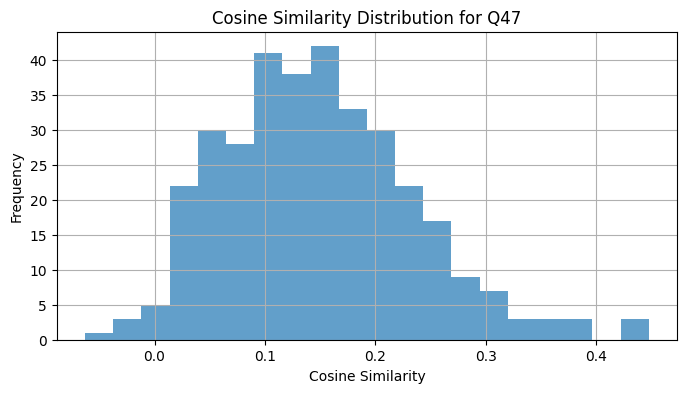

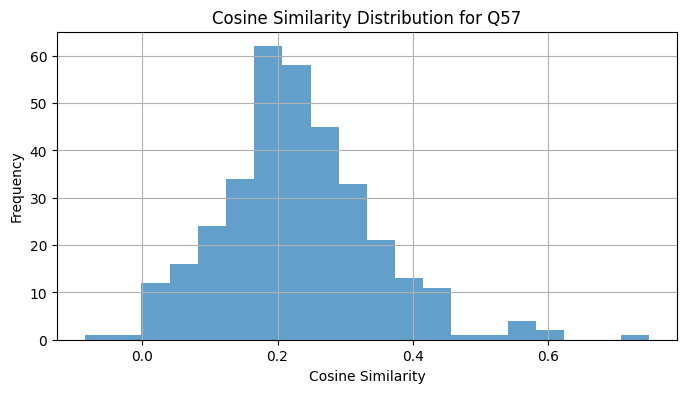

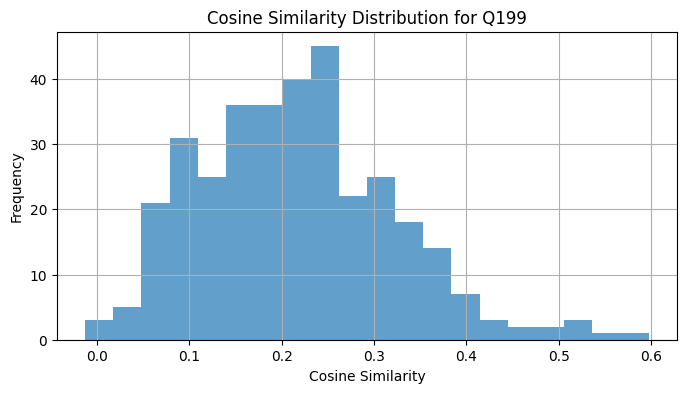

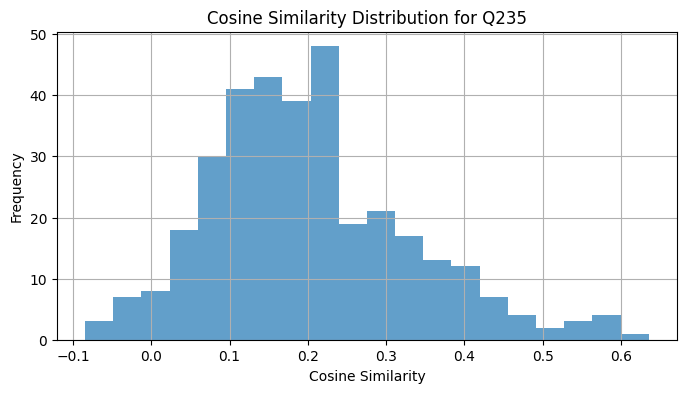

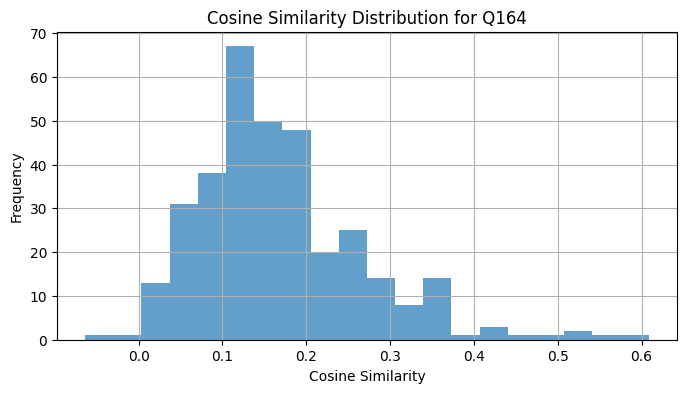

In [36]:
# Compute embeddings in a subprocess to fix libomp conflict between PyTorch (sentence-transformers) and XGBoost
import subprocess, sys, pickle, tempfile, os

# Prepare metadata payload for subprocess
with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
    meta_path = f.name
    pickle.dump({"metadata": metadata, "target_questions": target_questions}, f)

subprocess_code = r'''
import pickle, sys, json
import numpy as np

with open(sys.argv[1], "rb") as f:
    data = pickle.load(f)

metadata = data["metadata"]
target_questions = data["target_questions"]

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

st_model = SentenceTransformer("all-MiniLM-L6-v2")

# Compute embeddings for all candidate variables
candidate_texts = {}
for section in metadata.values():
    for var_code, var_info in section.items():
        if var_code not in ["N_REGION_ISO", "B_COUNTRY"]:
            candidate_texts[var_code] = var_info["question"]

var_codes = list(candidate_texts.keys())
texts = [candidate_texts[v] for v in var_codes]
embeddings = st_model.encode(texts)

# Compute cosine similarities for each target
cosine_similarities = {}
for target_var in target_questions:
    target_text = None
    for section in metadata.values():
        if target_var in section:
            target_text = section[target_var]["question"]
            break
    target_emb = st_model.encode([target_text])
    
    cosine_similarities[target_var] = {}
    for i, var_code in enumerate(var_codes):
        if var_code != target_var:
            sim = cosine_similarity(target_emb, embeddings[i:i+1])[0][0]
            cosine_similarities[target_var][var_code] = float(sim)

# Write results
with open(sys.argv[2], "wb") as f:
    pickle.dump(cosine_similarities, f)
'''

with tempfile.NamedTemporaryFile(suffix=".pkl", delete=False) as f:
    result_path = f.name

result = subprocess.run(
    [sys.executable, "-c", subprocess_code, meta_path, result_path],
    capture_output=True, text=True
)
os.unlink(meta_path)

if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError(f"Subprocess failed with exit code {result.returncode}")

with open(result_path, "rb") as f:
    cosine_similarities = pickle.load(f)
os.unlink(result_path)

print(f"Computed similarities for {len(cosine_similarities)} targets")
for t, cands in cosine_similarities.items():
    print(f"  {t}: {len(cands)} candidates")

# helper to get question text for a variable code
def get_question_text(var_code):
    for section in metadata.values():
        if var_code in section:
            return section[var_code]["question"]
    return None

# plot similarity distributions for each target variable
import matplotlib.pyplot as plt
for target_var, candidates in cosine_similarities.items():
    similarities = list(candidates.values())
    plt.figure(figsize=(8, 4))
    plt.hist(similarities, bins=20, alpha=0.7)
    plt.title(f"Cosine Similarity Distribution for {target_var}")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

In [37]:
# remove candidate variables with similarity > 0.85 for each target variable
similarity_threshold = 0.85
filtered_candidates = {}
for target_var, candidates in cosine_similarities.items():
    filtered_candidates[target_var] = {
        var: sim for var, sim in candidates.items() if sim <= similarity_threshold
    }

# print the remaining candidate variables for each target variable
print("\nRemaining candidate variables per target:")
for target_var, candidates in filtered_candidates.items():
    print(f"  {target_var}: {len(candidates)} candidates")

# print the amount of removed candidate variables for each target variable
print("\nRemoved candidate variables per target:")
for target_var in target_questions:
    original_count = len(cosine_similarities[target_var])
    filtered_count = len(filtered_candidates[target_var])
    removed_count = original_count - filtered_count
    print(f"  {target_var}: {removed_count} removed (similarity > {similarity_threshold})")


Remaining candidate variables per target:
  Q47: 340 candidates
  Q57: 340 candidates
  Q199: 340 candidates
  Q235: 340 candidates
  Q164: 340 candidates

Removed candidate variables per target:
  Q47: 0 removed (similarity > 0.85)
  Q57: 0 removed (similarity > 0.85)
  Q199: 0 removed (similarity > 0.85)
  Q235: 0 removed (similarity > 0.85)
  Q164: 0 removed (similarity > 0.85)


## Steps 3–5: Prepare data, train XGBoost, compute permutation importance

For each of the 25 target × country cells, we:
1. Filter to that country, select features from the filtered pool
2. Drop rows where the target is missing; drop features that are entirely missing for that country
3. Encode y as 0-indexed integer labels
4. Run 5-fold CV with XGBoost, computing permutation importance on each held-out fold
5. Store results

In [38]:
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# Admin/ID columns to always exclude
admin_cols = [
    "version", "doi", "A_WAVE", "A_YEAR", "A_STUDY", "B_COUNTRY", "B_COUNTRY_ALPHA",
    "C_COW_NUM", "C_COW_ALPHA", "D_INTERVIEW", "S007", "J_INTDATE",
    "FW_START", "FW_END", "K_TIME_START", "K_TIME_END", "K_DURATION", "Q_MODE",
    "N_REGION_ISO", "N_REGION_WVS", "N_REGION_NUTS2", "N_REG_NUTS1", "N_TOWN",
    "G_TOWNSIZE", "G_TOWNSIZE2", "H_SETTLEMENT", "H_URBRURAL", "I_PSU",
    "O1_LONGITUDE", "O2_LATITUDE", "L_INTERVIEWER_NUMBER", "S_INTLANGUAGE",
    "LNGE_ISO", "E_RESPINT", "F_INTPRIVACY", "E1_LITERACY",
    "W_WEIGHT", "S018", "PWGHT", "S025"
]

def make_clf():
    """Create a fresh XGBClassifier instance."""
    return xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    )

# Collect all results
all_results = []
cv_summaries = []

for target_var in target_questions:
    # Get filtered feature pool for this target (from Step 2)
    feature_vars = [v for v in filtered_candidates[target_var].keys()
                    if v in wvs_data_filtered.columns and v not in admin_cols]
    
    print(f"\n{'='*60}")
    print(f"TARGET: {target_var} — {get_question_text(target_var)}")
    print(f"Feature pool size: {len(feature_vars)}")
    
    for country_code, country_name in countries_map.items():
        print(f"\n  --- {country_name} ({country_code}) ---")
        
        # Filter to this country
        country_mask = wvs_data_filtered["B_COUNTRY"] == country_code
        country_data = wvs_data_filtered.loc[country_mask].copy()
        
        # Get target and drop missing
        y_raw = country_data[target_var]
        valid_mask = y_raw.notna()
        country_data = country_data.loc[valid_mask]
        y_raw = y_raw.loc[valid_mask]
        
        print(f"  n after dropping missing target: {len(country_data)}")
        
        # Flag low sample sizes — permutation importance will be unstable
        if len(country_data) < 100:
            print(f"  WARNING: n < 100 — permutation importance will be unstable for this cell")
        
        # Select features, drop columns that are entirely missing for this country
        X = country_data[feature_vars].copy()
        cols_all_missing = X.columns[X.isna().all()]
        if len(cols_all_missing) > 0:
            print(f"  Dropped {len(cols_all_missing)} features (entirely missing in this country)")
            X = X.drop(columns=cols_all_missing)
        
        print(f"  Features used: {X.shape[1]}")
        
        # Encode y as 0-indexed integers
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y_raw.astype(int)), index=y_raw.index)
        n_classes = len(le.classes_)
        
        # Check class distribution
        class_counts = y.value_counts()
        majority_pct = class_counts.max() / len(y)
        min_class_n = class_counts.min()
        print(f"  Classes: {n_classes}, majority baseline: {majority_pct:.3f}")
        
        # Drop classes with fewer than 5 observations
        if min_class_n < 5:
            rare_classes = class_counts[class_counts < 5].index.tolist()
            print(f"  WARNING: dropping {len(rare_classes)} classes with < 5 observations")
            keep_mask = ~y.isin(rare_classes)
            X = X.loc[keep_mask]
            y_raw = y_raw.loc[keep_mask]
            # Re-encode after dropping rare classes
            le = LabelEncoder()
            y = pd.Series(le.fit_transform(y_raw.astype(int)), index=y_raw.index)
            n_classes = len(le.classes_)
            class_counts = y.value_counts()
            majority_pct = class_counts.max() / len(y)
            print(f"  After filtering: {len(y)} samples, {n_classes} classes, majority baseline: {majority_pct:.3f}")
        
        if n_classes < 2:
            print(f"  SKIPPING: only 1 class remaining")
            continue
        
        kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
        # Cross-validated accuracy (fresh clf per fold via cross_val_score)
        cv_scores = cross_val_score(make_clf(), X, y, cv=kf, scoring='accuracy')
        print(f"  CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f} (baseline: {majority_pct:.3f})")
        
        cv_summaries.append({
            "target_variable": target_var,
            "country": country_code,
            "country_name": country_name,
            "n_samples": len(y),
            "n_features": X.shape[1],
            "n_classes": n_classes,
            "majority_baseline": round(majority_pct, 3),
            "cv_accuracy_mean": round(cv_scores.mean(), 3),
            "cv_accuracy_std": round(cv_scores.std(), 3),
            "low_n_warning": len(y) < 100,
        })
        
        # Permutation importance via 5-fold CV
        fold_importances = []
        
        for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X, y)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            # Fresh classifier for each fold to avoid stale classes_ state
            fold_clf = make_clf()
            fold_clf.fit(X_train, y_train)
            
            result = permutation_importance(
                fold_clf, X_test, y_test,
                n_repeats=10,
                random_state=42,
                scoring='accuracy'
            )
            fold_importances.append(result.importances_mean)
        
        # Average across folds
        mean_imp = np.mean(fold_importances, axis=0)
        std_imp = np.std(fold_importances, axis=0)
        
        # Store results
        for i, feat in enumerate(X.columns):
            all_results.append({
                "target_variable": target_var,
                "country": country_code,
                "feature_variable": feat,
                "importance_mean": mean_imp[i],
                "importance_std": std_imp[i],
            })
        
        # Show top 5 features
        top_idx = np.argsort(mean_imp)[::-1][:5]
        print(f"  Top 5 features:")
        for idx in top_idx:
            feat_name = X.columns[idx]
            desc = ""
            for section in metadata.values():
                if feat_name in section:
                    desc = section[feat_name]["description"]
                    break
            print(f"    {feat_name} ({desc}): {mean_imp[idx]:.4f} ± {std_imp[idx]:.4f}")

print("\n\nDone! All 25 cells processed.")


TARGET: Q47 — All in all, how would you describe your state of health these days?
Feature pool size: 340

  --- Germany (276) ---
  n after dropping missing target: 1525
  Dropped 52 features (entirely missing in this country)
  Features used: 288
  Classes: 5, majority baseline: 0.462
  CV accuracy: 0.477 ± 0.020 (baseline: 0.462)
  Top 5 features:
    Q262 (Age): 0.0141 ± 0.0135
    Q46 (Feeling of happiness): 0.0066 ± 0.0087
    Q170 (Belief that only one's own religion is acceptable): 0.0063 ± 0.0054
    Q120 (Perceived risk of accountability for bribery): 0.0056 ± 0.0066
    Q49 (Overall satisfaction with life): 0.0053 ± 0.0135

  --- Nigeria (566) ---
  n after dropping missing target: 1235
  Dropped 50 features (entirely missing in this country)
  Features used: 290
  Classes: 5, majority baseline: 0.438
  CV accuracy: 0.587 ± 0.011 (baseline: 0.438)
  Top 5 features:
    Q46 (Feeling of happiness): 0.0470 ± 0.0120
    Q49 (Overall satisfaction with life): 0.0117 ± 0.0103
    Q

## Step 6: Assemble the output table

In [39]:
# save full importance table
importance_df = pd.DataFrame(all_results)
importance_df.to_csv("phase0a_importance_table.csv", index=False)
print(f"Saved importance table: {importance_df.shape[0]} rows")
print(f"Unique targets: {importance_df['target_variable'].nunique()}")
print(f"Unique countries: {importance_df['country'].nunique()}")
importance_df.head(10)

# save CV summaries for reference
cv_df = pd.DataFrame(cv_summaries)
cv_df.to_csv("phase0a_cv_summaries.csv", index=False)
print("\nCV Summaries:")
cv_df

Saved importance table: 7060 rows
Unique targets: 5
Unique countries: 5

CV Summaries:


,target_variable,country,country_name,n_samples,n_features,n_classes,majority_baseline,cv_accuracy_mean,cv_accuracy_std,low_n_warning
0,Q47,276,Germany,1525,288,5,0.462,0.477,0.020,False
1,Q47,566,Nigeria,1235,290,5,0.438,0.587,0.011,False
2,Q47,392,Japan,1341,288,5,0.377,0.441,0.016,False
3,Q47,76,Brazil,1757,290,5,0.453,0.496,0.008,False
4,Q47,818,Egypt,1200,256,5,0.503,0.598,0.031,False
5,Q57,276,Germany,1482,288,2,0.540,0.748,0.015,False
6,Q57,566,Nigeria,1230,290,2,0.873,0.889,0.025,False
7,Q57,392,Japan,1281,288,2,0.644,0.715,0.022,False
8,Q57,76,Brazil,1730,290,2,0.934,0.936,0.005,False
9,Q57,818,Egypt,1197,256,2,0.926,0.921,0.017,False


## Step 7: Compute cross-country rank correlations

In [ ]:
from scipy.stats import spearmanr

rank_corr_records = []
country_codes = list(countries_map.keys())
country_names = list(countries_map.values())

print("Cross-country Spearman rank correlations of feature importance:\n")

for target_var in target_questions:
    target_data = importance_df[importance_df["target_variable"] == target_var]
    
    # Pivot: rows = features, columns = countries, values = importance_mean
    # Only use features present in ALL countries for fair comparison
    pivot = target_data.pivot_table(
        index="feature_variable", columns="country", values="importance_mean"
    ).dropna()
    
    print(f"\n{'='*50}")
    print(f"TARGET: {target_var} — {get_question_text(target_var)}")
    print(f"Features in common across all countries: {len(pivot)}")
    
    # Compute pairwise Spearman correlations
    corr_matrix = pd.DataFrame(
        np.ones((len(country_codes), len(country_codes))),
        index=country_names, columns=country_names
    )
    
    for i, c1 in enumerate(country_codes):
        for j, c2 in enumerate(country_codes):
            if i < j and c1 in pivot.columns and c2 in pivot.columns:
                rho, pval = spearmanr(pivot[c1], pivot[c2])
                corr_matrix.iloc[i, j] = rho
                corr_matrix.iloc[j, i] = rho
                rank_corr_records.append({
                    "target_variable": target_var,
                    "country_1": c1,
                    "country_2": c2,
                    "spearman_rho": round(rho, 4),
                    "p_value": round(pval, 6),
                })
    
    print(f"\nCorrelation matrix:")
    print(corr_matrix.round(3).to_string())
    
    # Mean pairwise rho (key diagnostic)
    upper_triangle = corr_matrix.values[np.triu_indices(len(country_codes), k=1)]
    mean_rho = np.mean(upper_triangle)
    print(f"\n  >>> Mean pairwise ρ: {mean_rho:.3f}")
    if mean_rho > 0.8:
        print(f"  Interpretation: high: structure is largely universal")
    elif mean_rho > 0.5:
        print(f"  Interpretation: moderate: some cross-national variation")
    else:
        print(f"  Interpretation: low: substantial cross-national variation")

# Save rank correlations
rank_corr_df = pd.DataFrame(rank_corr_records)
rank_corr_df.to_csv("phase0a_rank_correlations.csv", index=False)
print(f"\nSaved rank correlations: {len(rank_corr_records)} pairs")

Cross-country Spearman rank correlations of feature importance:


TARGET: Q47 — All in all, how would you describe your state of health these days?
Features in common across all countries: 250

Correlation matrix:
         Germany  Nigeria  Japan  Brazil  Egypt
Germany    1.000   -0.057 -0.088   0.014 -0.021
Nigeria   -0.057    1.000  0.039   0.037  0.074
Japan     -0.088    0.039  1.000   0.134  0.276
Brazil     0.014    0.037  0.134   1.000  0.095
Egypt     -0.021    0.074  0.276   0.095  1.000

  >>> Mean pairwise ρ: 0.050
  Interpretation: LOW — substantial cross-national variation

TARGET: Q57 — Generally speaking, would you say that most people can be trusted or that you need to be very careful in dealing with people?
Features in common across all countries: 250

Correlation matrix:
         Germany  Nigeria  Japan  Brazil  Egypt
Germany    1.000   -0.028  0.106  -0.066  0.001
Nigeria   -0.028    1.000 -0.019  -0.098  0.075
Japan      0.106   -0.019  1.000  -0.023  0.084
Brazil  

## Step 8: Create heatmaps

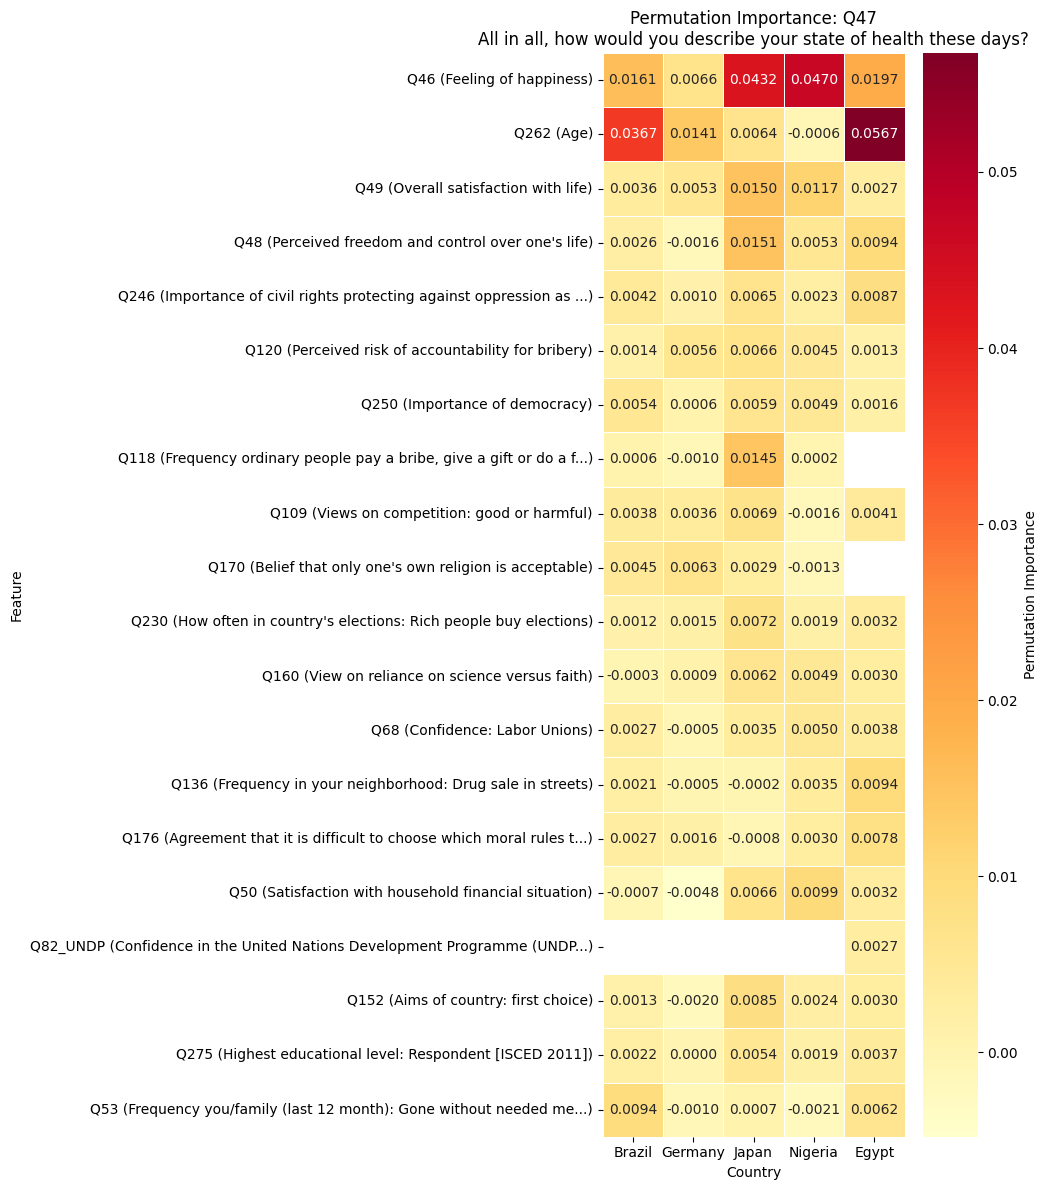

Saved: phase0a_heatmap_Q47.png



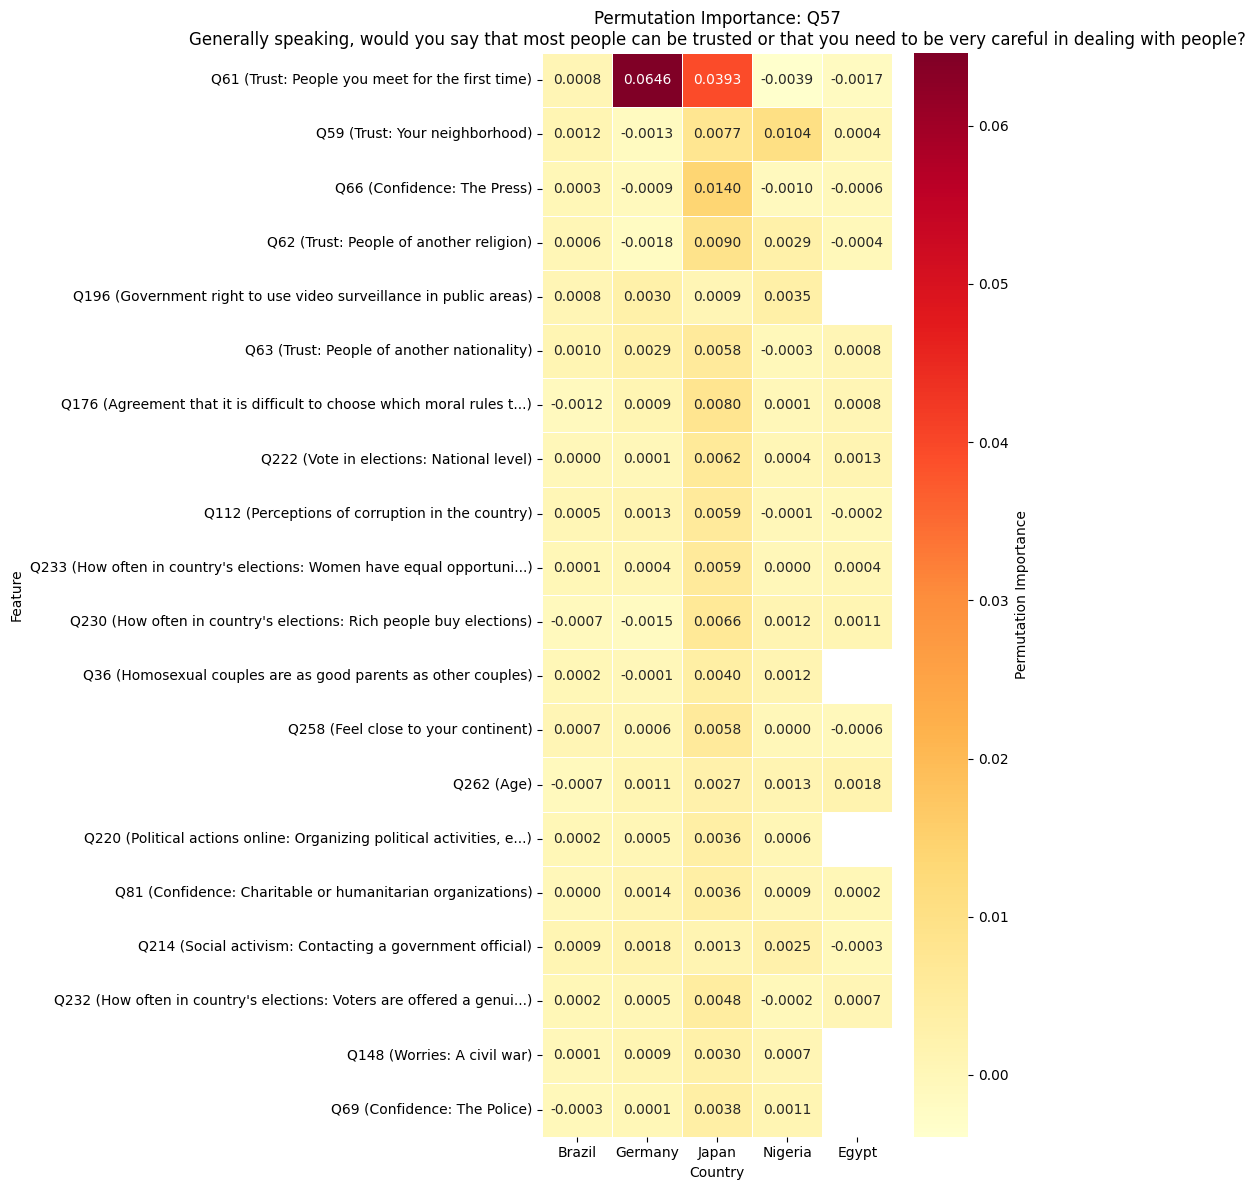

Saved: phase0a_heatmap_Q57.png



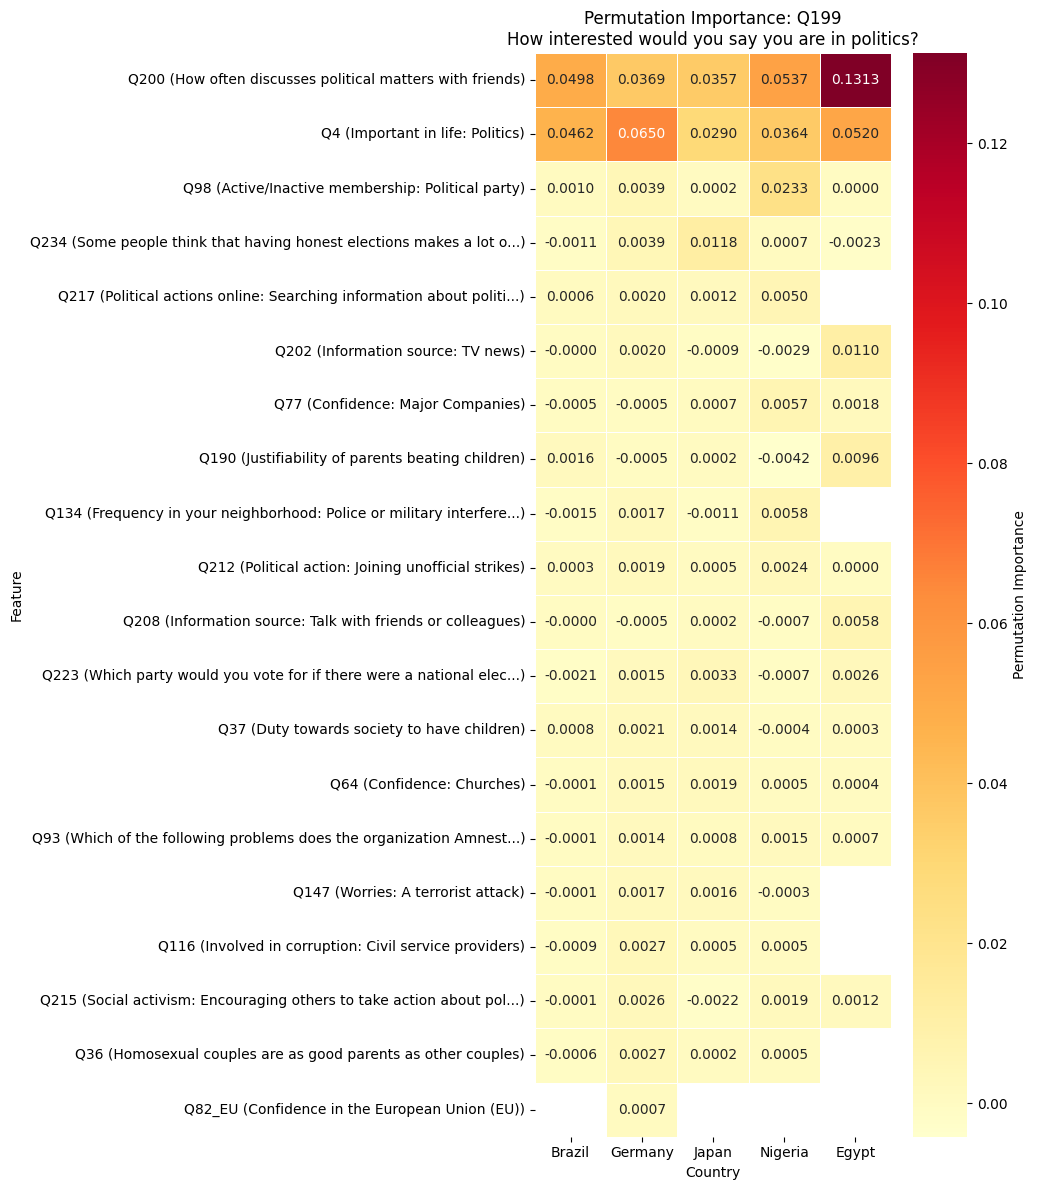

Saved: phase0a_heatmap_Q199.png



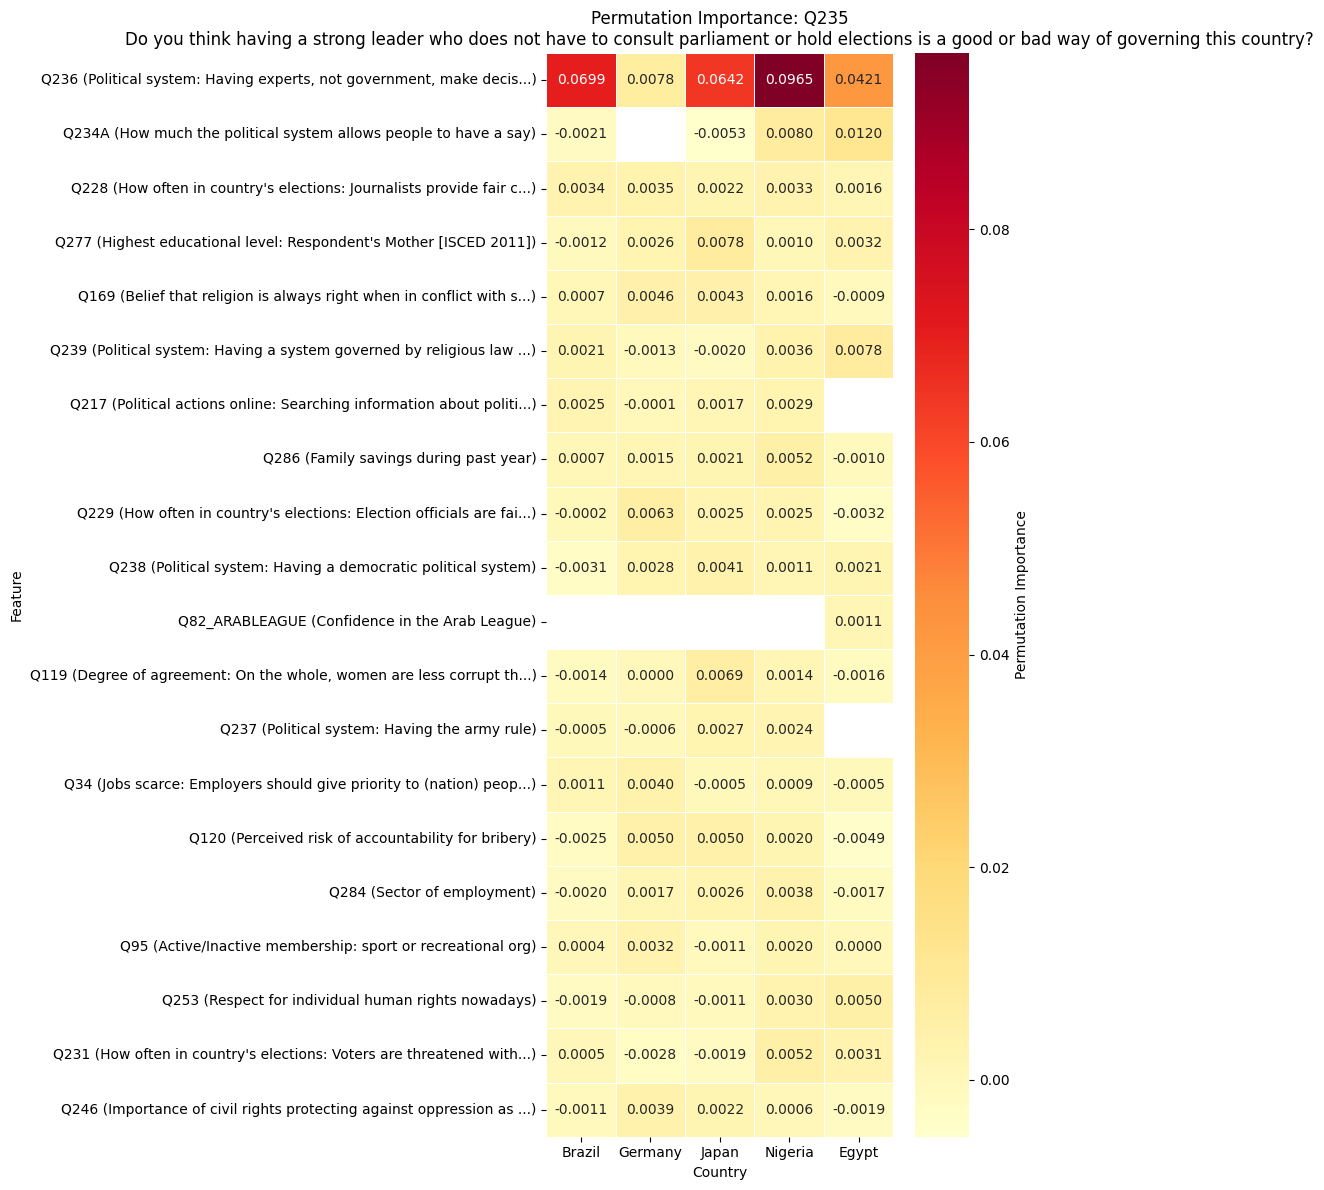

Saved: phase0a_heatmap_Q235.png



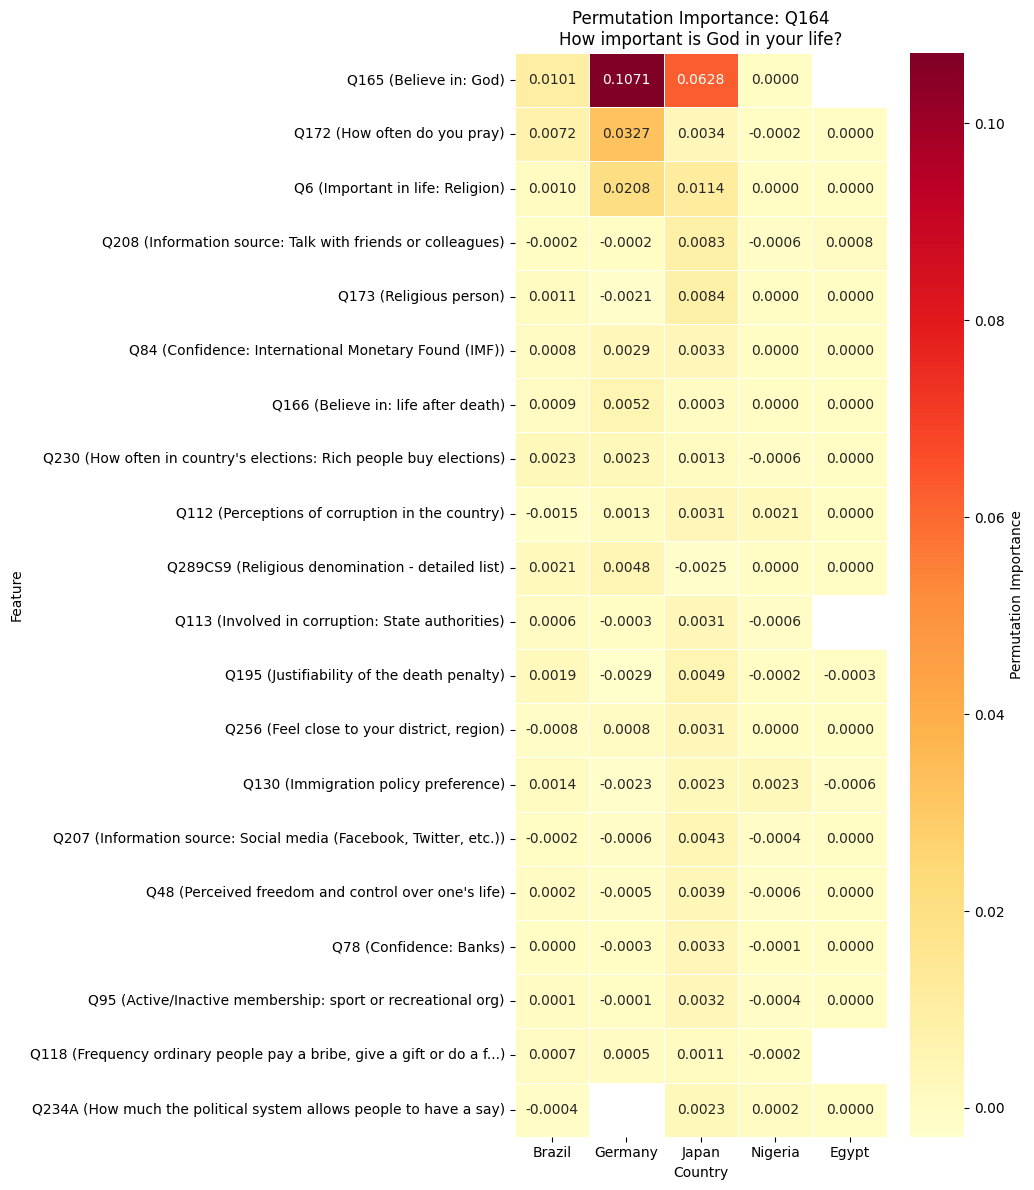

Saved: phase0a_heatmap_Q164.png



In [47]:
import seaborn as sns

def get_description(var_code):
    """Get short description for a variable from metadata."""
    for section in metadata.values():
        if var_code in section:
            desc = section[var_code]["description"]
            # Truncate long descriptions for readability
            return desc[:60] + "..." if len(desc) > 60 else desc
    return var_code

for target_var in target_questions:
    target_data = importance_df[importance_df["target_variable"] == target_var]
    
    # Pivot: features × countries
    pivot = target_data.pivot_table(
        index="feature_variable", columns="country", values="importance_mean"
    )
    
    # Rename columns to country names
    pivot.columns = [countries_map.get(c, c) for c in pivot.columns]
    
    # Select top 20 features by average importance across countries
    avg_importance = pivot.mean(axis=1).sort_values(ascending=False)
    top_features = avg_importance.head(20).index
    pivot_top = pivot.loc[top_features]
    
    # Replace variable codes with descriptions for row labels
    pivot_top.index = [f"{idx} ({get_description(idx)})" for idx in pivot_top.index]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 12))
    sns.heatmap(
        pivot_top,
        cmap="YlOrRd",
        annot=True,
        fmt=".4f",
        linewidths=0.5,
        ax=ax,
        cbar_kws={"label": "Permutation Importance"}
    )
    
    target_desc = get_question_text(target_var)
    ax.set_title(f"Permutation Importance: {target_var}\n{target_desc}", fontsize=12)
    ax.set_xlabel("Country")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    
    fig.savefig(f"phase0a_heatmap_{target_var}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: phase0a_heatmap_{target_var}.png\n")